In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [67]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [68]:
#Loading External_Cibil_Dataset
df1= pd.read_excel("../data/External_Cibil_Dataset.xlsx")

In [459]:
df1.sample(10)

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_utilization,CC_Flag,PL_utilization,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
13965,13966,90,35,1,26,82,21,2,7,5,33,33,10,1,10,5,10,0,0,0,0,0,0,0,0,0,3,6,4,0,0,0,0,0,18,1,1,1,Married,SSC,36,M,45000,68,0.276,0.00,0.356,0.867,1,-99999.000,0,0.000,0.0,0.0,0.0,2.140,1,0,ConsumerLoan,ConsumerLoan,694,P2
21286,21287,37,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,3,2,2,0,0,0,0,0,0,0,0,0,0,7,2,2,2,0,0,0,12,4,3,2,Married,OTHERS,37,M,25000,245,0.444,0.75,0.939,-99999.000,0,1.000,1,0.000,1.0,0.0,1.0,4.520,1,0,CC,others,693,P2
15411,15412,2437,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2808,0,0,0,Married,OTHERS,43,M,11000,295,0.000,0.00,0.000,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,-99999.000,0,0,others,others,705,P1
14454,14455,-99999,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,0,6,4,4,4,Married,SSC,29,M,20000,18,1.000,1.00,0.800,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,1.400,0,0,ConsumerLoan,others,656,P4
42841,42842,1319,-99999,-99999,0,-99999,0,0,0,0,-99999,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,2,1,1,1,Single,GRADUATE,25,M,15000,113,0.000,0.00,0.000,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,-99999.000,0,0,others,others,686,P2
10297,10298,71,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,37,5,12,0,0,0,0,0,0,0,0,0,0,8,0,0,0,4,2,3,3,6,4,2,Married,UNDER GRADUATE,35,M,30000,68,0.545,0.60,0.826,-99999.000,0,-99999.000,0,0.667,0.0,0.5,0.0,1.211,1,0,ConsumerLoan,ConsumerLoan,691,P2
4575,4576,85,4,4,1,30,30,1,1,0,30,30,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,4,1,1,1,1,1,1,9,3,3,2,Single,OTHERS,23,M,20000,54,1.000,0.50,0.522,-99999.000,0,0.842,1,1.000,1.0,1.0,1.0,0.499,0,0,others,ConsumerLoan,653,P4
43938,43939,197,19,18,2,35,5,0,0,0,0,0,1,0,11,0,0,0,0,0,0,0,0,0,0,0,5,3,0,0,0,0,0,0,19,3,3,3,Married,POST-GRADUATE,32,M,15000,131,0.048,0.00,1.034,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,-99999.000,1,0,ConsumerLoan,ConsumerLoan,668,P3
27923,27924,-99999,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,-99999,Single,12TH,23,M,15000,16,1.000,0.00,0.874,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,-99999.000,0,0,others,others,672,P2
31753,31754,118,-99999,-99999,0,-99999,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0,0,0,0,1,5,2,1,Married,12TH,46,F,20000,239,0.333,0.00,0.000,-99999.000,0,-99999.000,0,0.000,0.0,0.0,0.0,0.670,0,0,ConsumerLoan,ConsumerLoan,684,P2


In [69]:
# Loading Internal_Bank_Dataset
df2= pd.read_excel("../data/Internal_Bank_Dataset.xlsx")

In [461]:
df2.sample(10)

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
43193,43194,3,1,2,1,0,0.333,0.000,0.667,0.333,1,0,0.333,0.000,0,0,0,3,0,0,0,0,3,0,44,3
35816,35817,1,1,0,0,1,0.000,1.000,0.000,1.000,0,1,0.000,1.000,0,1,0,0,0,0,0,1,0,0,21,21
28437,28438,4,1,3,3,0,0.750,0.000,0.750,0.250,3,0,0.750,0.000,1,0,0,3,0,0,1,0,4,0,25,2
18892,18893,4,1,3,2,0,0.500,0.000,0.750,0.250,2,0,0.500,0.000,1,0,0,2,0,0,0,0,4,2,70,6
12783,12784,10,6,4,0,0,0.000,0.000,0.400,0.600,3,2,0.300,0.200,1,2,0,0,5,0,0,10,0,3,53,9
15761,15762,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,0,0,1,0,0,0,0,1,0,42,42
12081,12082,6,3,3,2,2,0.333,0.333,0.500,0.500,2,2,0.333,0.333,1,0,0,3,1,0,1,1,5,1,34,5
9485,9486,1,1,0,0,1,0.000,1.000,0.000,1.000,1,1,1.000,1.000,0,0,0,1,0,0,0,0,1,0,10,10
3697,3698,5,4,1,0,0,0.000,0.000,0.200,0.800,0,0,0.000,0.000,0,0,0,0,4,0,0,5,0,1,101,23
45501,45502,1,0,1,1,0,1.000,0.000,1.000,0.000,1,0,1.000,0.000,0,0,0,1,0,0,0,0,1,0,3,3


In [462]:
df1.shape

(51336, 62)

In [463]:
df2.shape

(51336, 26)

In [70]:
#Merging the 2 dataframes on Prospect_id
df = pd.merge(df1, df2, on="PROSPECTID")

In [6]:
df.shape

(51336, 87)

In [71]:
# Droping the id column
df = df.drop(columns=["PROSPECTID"])

In [467]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 86 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   time_since_recent_payment     51336 non-null  int64  
 1   time_since_first_deliquency   51336 non-null  int64  
 2   time_since_recent_deliquency  51336 non-null  int64  
 3   num_times_delinquent          51336 non-null  int64  
 4   max_delinquency_level         51336 non-null  int64  
 5   max_recent_level_of_deliq     51336 non-null  int64  
 6   num_deliq_6mts                51336 non-null  int64  
 7   num_deliq_12mts               51336 non-null  int64  
 8   num_deliq_6_12mts             51336 non-null  int64  
 9   max_deliq_6mts                51336 non-null  int64  
 10  max_deliq_12mts               51336 non-null  int64  
 11  num_times_30p_dpd             51336 non-null  int64  
 12  num_times_60p_dpd             51336 non-null  int64  
 13  n

In [72]:
# Replacing -99999 with NAN 
df.replace(-99999, np.nan, inplace=True)

In [73]:
# Calculating percengate of missing values for each column 
missing_percent = df.isna().mean()*100

In [470]:
missing_percent

time_since_recent_payment        8.358657
time_since_first_deliquency     70.026882
time_since_recent_deliquency    70.026882
num_times_delinquent             0.000000
max_delinquency_level           70.026882
max_recent_level_of_deliq        0.000000
num_deliq_6mts                   0.000000
num_deliq_12mts                  0.000000
num_deliq_6_12mts                0.000000
max_deliq_6mts                  25.109085
max_deliq_12mts                 21.100203
num_times_30p_dpd                0.000000
num_times_60p_dpd                0.000000
num_std                          0.000000
num_std_6mts                     0.000000
num_std_12mts                    0.000000
num_sub                          0.000000
num_sub_6mts                     0.000000
num_sub_12mts                    0.000000
num_dbt                          0.000000
num_dbt_6mts                     0.000000
num_dbt_12mts                    0.000000
num_lss                          0.000000
num_lss_6mts                     0

In [74]:
# Selecting all the columns with missing percentage >40
cols_to_drop = missing_percent[missing_percent > 40].index
cols_to_drop

Index(['time_since_first_deliquency', 'time_since_recent_deliquency',
       'max_delinquency_level', 'CC_utilization', 'PL_utilization',
       'max_unsec_exposure_inPct'],
      dtype='object')

In [75]:
# Dropping the selected columns
df.drop(columns=cols_to_drop, inplace=True)

In [473]:
df.sample(10)

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
24284,NaN,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,12.0,1.0,1.0,1.0,3.0,3.0,3.0,2.0,12.0,12.0,12.0,Single,GRADUATE,28,M,25000,75,1.000,1.000,0.700,0,0,1.00,1.0,1.000,1.0,0,0,ConsumerLoan,PL,609,P4,1,0,1,1,0,1.000,0.000,1.000,0.000,1,0,1.000,0.000,1,0,0,1,0,0,0,0,1,0,2.0,2.0
22068,59.0,0,0,0,0,0,0.0,0.0,0,0,3,3,3,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,92.0,2.0,1.0,0.0,Married,12TH,50,M,16000,74,1.000,0.667,0.772,0,1,0.00,0.0,0.000,0.0,1,0,others,others,674,P2,3,0,3,2,0,0.667,0.000,1.000,0.000,3,0,1.000,0.000,1,0,0,0,1,0,1,2,1,1,11.0,3.0
46406,NaN,0,0,0,0,0,NaN,NaN,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Single,12TH,43,F,20000,154,1.000,0.000,1.000,0,0,0.00,0.0,0.000,0.0,1,0,others,others,677,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,1,0,0,0,1,0,0,1,0,0,31.0,31.0
23965,123.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,2.0,Married,UNDER GRADUATE,40,F,31500,54,1.000,0.000,0.000,0,0,0.00,0.0,0.000,0.0,0,0,others,others,660,P3,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,27.0,27.0
9277,56.0,9,29,4,9,5,3.0,29.0,0,0,50,10,20,0,0,0,0,0,0,0,0,0,3,17.0,3.0,0.0,2.0,9.0,0.0,0.0,1.0,3.0,1.0,1.0,Married,12TH,51,M,30000,65,0.316,0.000,0.805,1,1,0.00,0.0,0.000,0.0,1,1,ConsumerLoan,PL,721,P1,19,13,6,0,0,0.000,0.000,0.316,0.684,1,0,0.053,0.000,2,1,1,0,4,2,6,7,12,5,145.0,10.0
36710,17.0,0,0,0,0,0,0.0,0.0,0,0,7,5,7,0,0,0,0,0,0,0,0,0,0,37.0,0.0,0.0,0.0,8.0,3.0,4.0,4.0,13.0,8.0,6.0,Married,12TH,26,M,25000,65,0.233,0.571,0.555,0,1,0.75,0.0,0.375,0.0,1,0,ConsumerLoan,ConsumerLoan,677,P2,30,23,7,4,4,0.133,0.133,0.233,0.767,7,8,0.233,0.267,2,0,0,23,3,0,1,3,27,3,77.0,2.0
33650,74.0,0,0,0,0,0,0.0,0.0,0,0,89,10,41,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,249.0,1.0,0.0,0.0,Married,UNDER GRADUATE,35,F,13000,60,0.086,0.200,1.009,0,0,0.00,0.0,0.000,0.0,1,0,others,others,732,P1,35,32,3,1,2,0.029,0.057,0.086,0.914,5,6,0.143,0.171,1,0,0,0,19,0,0,35,0,16,84.0,2.0
45091,NaN,2,27,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,27,2.0,0.0,0.0,0.0,0.0,0.0,0.0,113.0,1.0,1.0,0.0,Married,OTHERS,38,F,12000,194,1.000,0.000,0.961,0,0,0.00,0.0,0.000,0.0,0,1,others,HL,670,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,1,0,0,0,0,1,0,1,0,0,30.0,30.0
16548,440.0,0,0,0,0,0,NaN,NaN,0,0,32,4,10,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1262.0,0.0,0.0,0.0,Married,PROFESSIONAL,39,M,62750,185,1.000,0.000,0.000,0,0,0.00,0.0,0.000,0.0,0,0,others,others,694,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,42.0,42.0
24579,59.0,0,0,0,0,0,0.0,0.0,0,0,5,3,5,0,0,0,0,0,0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,202.0,1.0,0.0,0.0,Married,OTHERS,34,M,25000,126,1.000,0.000,0.440,0,0,0.00,0.0,0.000,0.0,0,0,others,others,681,P2,2,0,2,0,0,0.000,0.000,1.000,0.000,1,0,0.500,0.000,1,0,0,0,0,0,0,1,1,2,18.0,7.0


In [474]:
df.shape

(51336, 80)

In [475]:
#Creating a df with those columns which has missing values
cols = [
    "tot_enq",
    "CC_enq",
    "CC_enq_L6m",
    "CC_enq_L12m",
    "PL_enq",
    "PL_enq_L6m",
    "PL_enq_L12m",
    "time_since_recent_enq",
    "enq_L12m",
    "enq_L6m",
    "enq_L3m",
    "AGE"
]
df_enquiry = df[cols]
df_enquiry_clean = df_enquiry.dropna()

In [476]:
df_enquiry_clean.sample(10)

,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,AGE
8720,6.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,2.0,1.0,1.0,47
28621,12.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,5.0,3.0,2.0,29
48175,17.0,0.0,0.0,0.0,1.0,0.0,1.0,9.0,9.0,1.0,1.0,54
45037,2.0,0.0,0.0,0.0,0.0,0.0,0.0,360.0,1.0,0.0,0.0,27
21294,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,1.0,34
41558,36.0,10.0,4.0,5.0,3.0,1.0,1.0,15.0,23.0,17.0,6.0,29
27966,8.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,3.0,3.0,29
14937,10.0,0.0,0.0,0.0,3.0,1.0,3.0,13.0,10.0,8.0,7.0,39
20131,7.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,2.0,33
45577,7.0,0.0,0.0,0.0,2.0,0.0,0.0,240.0,3.0,0.0,0.0,31


In [477]:
tot_enq_counts = df.groupby("tot_enq").size()
print(tot_enq_counts)

tot_enq
1.0      9476
2.0      7802
3.0      6087
4.0      4626
5.0      3389
6.0      2600
7.0      1939
8.0      1531
9.0      1247
10.0      981
11.0      785
12.0      646
13.0      548
14.0      450
15.0      360
16.0      300
17.0      293
18.0      259
19.0      198
20.0      193
21.0      150
22.0      132
23.0      102
24.0      103
25.0       83
26.0       79
27.0       65
28.0       65
29.0       53
30.0       45
31.0       40
32.0       38
33.0       28
34.0       20
35.0       36
36.0       22
37.0       20
38.0       17
39.0       18
40.0        9
41.0       17
42.0       11
43.0       15
44.0        5
45.0        7
46.0       11
47.0       16
48.0        6
49.0        9
50.0        7
51.0        9
52.0        3
53.0        2
54.0        8
55.0        5
56.0        3
57.0        3
58.0        5
59.0        3
61.0        2
62.0        4
63.0        2
64.0        1
65.0        1
66.0        1
67.0        1
68.0        5
69.0        1
70.0        1
72.0        1
73.0        

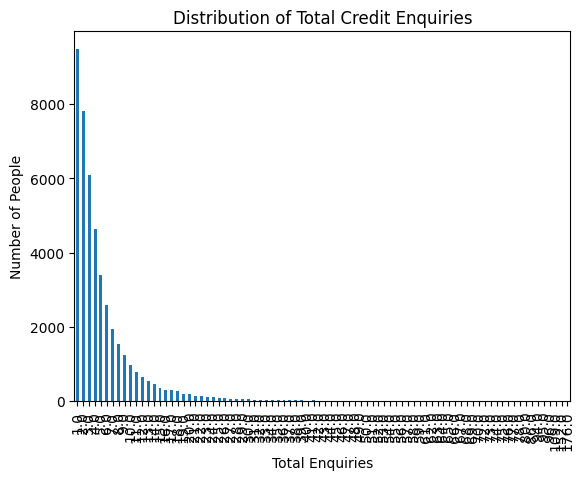

In [478]:
tot_enq_counts.plot(kind="bar")

plt.xlabel("Total Enquiries")
plt.ylabel("Number of People")
plt.title("Distribution of Total Credit Enquiries")
plt.show()

In [76]:
# Filling all the missing values with median
num_cols = df.select_dtypes(include=['int64','float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [13]:
df.isna().sum()

time_since_recent_payment     0
num_times_delinquent          0
max_recent_level_of_deliq     0
num_deliq_6mts                0
num_deliq_12mts               0
num_deliq_6_12mts             0
max_deliq_6mts                0
max_deliq_12mts               0
num_times_30p_dpd             0
num_times_60p_dpd             0
num_std                       0
num_std_6mts                  0
num_std_12mts                 0
num_sub                       0
num_sub_6mts                  0
num_sub_12mts                 0
num_dbt                       0
num_dbt_6mts                  0
num_dbt_12mts                 0
num_lss                       0
num_lss_6mts                  0
num_lss_12mts                 0
recent_level_of_deliq         0
tot_enq                       0
CC_enq                        0
CC_enq_L6m                    0
CC_enq_L12m                   0
PL_enq                        0
PL_enq_L6m                    0
PL_enq_L12m                   0
time_since_recent_enq         0
enq_L12m

In [77]:
# Creating new features

df["active_loan_ratio"] = df["Tot_Active_TL"] / df["Total_TL"]          #Active loan ratio
df["loan_income_ratio"] = (df["Total_TL"]*100) / df["NETMONTHLYINCOME"]       #Loan income ratio
df["recent_enq_ratio"] = df["enq_L3m"] / (df["tot_enq"] + 1)            #Recent inquiry ratio
df["total_delinquency"] = df["num_deliq_6mts"] + df["num_deliq_12mts"]  #Total deliquency score
df["credit_activity_gap"] = df["Age_Oldest_TL"] - df["Age_Newest_TL"]   #Credit activty gap

flag_cols = ["HL_Flag", "GL_Flag", "PL_Flag", "CC_Flag"]
df["total_loan_flags"] = df[flag_cols].sum(axis=1)

df["secured_loan_flags"] = df[["HL_Flag","GL_Flag"]].sum(axis=1)
df["unsecured_loan_flags"] = df[["PL_Flag","CC_Flag"]].sum(axis=1)

In [32]:
df.sample(10)

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,active_loan_ratio,loan_income_ratio,recent_enq_ratio,total_delinquency,credit_activity_gap,total_loan_flags,secured_loan_flags,unsecured_loan_flags
4395,15.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,731.0,0.0,0.0,0.0,Married,12TH,48,F,39000,119,1.000,0.0,0.361,1,0,0.0,0.0,0.00,0.0,0,0,others,CC,687,P2,3,0,3,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,1,0,0,0,0,2,1,1,58.0,24.0,1.000000,0.007692,0.000000,0,34.0,1,0,1
26349,256.0,0,0,0,0,0,0.0,0.0,0,0,38,5,13,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,2.0,0.0,1.0,3.0,2.0,1.0,1.0,Married,GRADUATE,33,F,25000,105,0.333,0.0,0.897,0,1,0.0,0.0,0.00,0.0,0,0,others,PL,682,P2,3,2,1,0,0,0.000,0.000,0.333,0.667,1,1,0.333,0.333,0,0,0,0,0,0,3,0,3,0,35.0,9.0,0.333333,0.012000,0.250000,0,26.0,1,0,1
13,46.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,164.0,1.0,1.0,0.0,Married,SSC,39,M,25000,125,0.500,1.0,0.345,0,0,0.0,0.0,0.00,0.0,0,0,ConsumerLoan,ConsumerLoan,687,P2,2,1,1,1,0,0.500,0.000,0.500,0.500,1,1,0.500,0.500,0,0,0,2,0,0,0,0,2,0,16.0,5.0,0.500000,0.008000,0.000000,0,11.0,0,0,0
26353,102.0,2,88,0,0,0,0.0,0.0,2,2,53,2,11,0,0,0,0,0,0,0,0,0,88,1.0,0.0,0.0,0.0,1.0,1.0,1.0,136.0,1.0,1.0,0.0,Married,12TH,41,M,23000,223,0.200,0.5,0.995,0,0,1.0,0.0,1.00,0.0,1,0,PL,PL,683,P2,15,12,3,2,2,0.133,0.133,0.200,0.800,4,4,0.267,0.267,1,0,0,0,5,0,0,13,2,10,91.0,4.0,0.200000,0.065217,0.000000,0,87.0,1,1,0
11588,74.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14.0,6.0,0.0,0.0,4.0,3.0,3.0,8.0,6.0,6.0,1.0,Single,GRADUATE,22,M,14097,78,1.000,1.0,1.146,0,0,1.0,0.0,0.75,0.0,0,0,PL,PL,670,P2,1,0,1,1,0,1.000,0.000,1.000,0.000,1,0,1.000,0.000,1,0,0,0,0,0,0,0,1,1,2.0,2.0,1.000000,0.007094,0.066667,0,0.0,0,0,0
19965,71.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,Married,12TH,48,M,28000,66,1.000,0.0,0.914,0,0,0.0,0.0,0.00,0.0,0,0,others,others,689,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,1,0,1.000,0.000,0,1,0,0,0,0,0,1,0,0,7.0,7.0,1.000000,0.003571,0.250000,0,0.0,0,0,0
49850,121.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,Married,GRADUATE,28,M,26000,130,0.000,0.0,0.000,0,0,0.0,0.0,0.00,0.0,0,0,others,others,727,P1,2,2,0,0,1,0.000,0.500,0.000,1.000,0,1,0.000,0.500,0,1,0,0,0,0,0,2,0,1,187.0,27.0,0.000000,0.007692,0.250000,0,160.0,0,0,0
13738,146.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.0,0.0,0.0,0.0,2.0,0.0,1.0,236.0,2.0,0.0,0.0,Single,UNDER GRADUATE,30,M,30000,61,0.176,0.0,0.078,0,0,0.0,0.0,0.00,0.0,1,0,PL,ConsumerLoan,690,P2,17,14,3,0,0,0.000,0.000,0.176,0.824,1,1,0.059,0.059,0,0,0,10,3,0,0,3,14,4,58.0,10.0,0.176471,0.056667,0.000000,0,48.0,1,1,0
49574,83.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5.0,0.0,0.0,0.0,2.0,1.0,2.0,78.0,4.0,1.0,1.0,Married,12TH,32,M,25000,89,1.000,0.0,0.333,0,0,0.5,0.0,0.50,0.0,0,0,PL,others,674,P2,1,0

In [78]:
# Adjusting values with zero income

df["loan_income_ratio"].replace([np.inf, -np.inf], np.nan, inplace=True)
loan_income_median_value = df["loan_income_ratio"].median()
df["loan_income_ratio"].fillna(loan_income_median_value, inplace=True)


In [485]:
df.sample(10)

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,active_loan_ratio,loan_income_ratio,recent_enq_ratio,total_delinquency,credit_activity_gap
33154,43.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,11.0,5.0,5.0,Married,GRADUATE,43,M,30000,126,0.000,0.0,0.000,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,others,663,P3,1,1,0,0,1,0.000,1.000,0.000,1.000,1,1,1.000,1.000,0,0,0,1,0,0,0,0,1,0,9.0,9.0,0.000,0.003333,0.417,0,0
1564,47.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,7.0,1.0,1.0,1.0,5.0,5.0,5.0,22.0,6.0,6.0,2.0,Single,12TH,22,M,21000,46,0.400,1.0,0.811,1,0,1.0,1.0,1.000,1.0,1,0,PL,others,670,P2,5,3,2,2,0,0.400,0.000,0.400,0.600,2,1,0.400,0.200,0,1,1,1,2,0,0,3,2,0,20.0,4.0,0.400,0.023810,0.250,0,16
11689,315.0,9,26,4,9,5,26.0,73.0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,26,4.0,0.0,0.0,0.0,0.0,0.0,0.0,522.0,0.0,0.0,0.0,Married,12TH,40,F,21000,187,1.000,0.0,0.217,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,679,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,0,0,1,0,0,0,0,1,0,21.0,21.0,1.000,0.004762,0.000,13,0
36788,51.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,217.0,1.0,0.0,0.0,Married,12TH,33,M,50000,71,1.000,0.0,0.173,0,0,0.0,0.0,0.000,0.0,0,0,others,others,692,P2,2,0,2,0,0,0.000,0.000,1.000,0.000,1,0,0.500,0.000,0,1,0,1,0,0,0,1,1,0,28.0,7.0,1.000,0.004000,0.000,0,21
50408,55.0,2,21,0,0,0,0.0,0.0,0,0,68,8,20,0,0,0,0,0,0,0,0,0,21,20.0,2.0,0.0,0.0,8.0,1.0,1.0,2.0,7.0,7.0,7.0,Married,POST-GRADUATE,45,M,35000,48,0.615,1.0,0.583,1,1,1.0,0.0,0.125,0.0,1,1,others,PL,659,P3,13,5,8,1,1,0.077,0.077,0.615,0.385,1,1,0.077,0.077,1,3,2,0,2,2,3,8,5,1,121.0,2.0,0.615,0.037143,0.333,0,119
14799,87.0,12,30,0,1,1,0.0,30.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,30,9.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,1.0,1.0,Married,12TH,35,M,22000,192,0.500,0.5,0.519,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,others,695,P2,8,4,4,1,0,0.125,0.000,0.500,0.500,2,0,0.250,0.000,1,6,0,2,0,0,0,6,2,0,149.0,5.0,0.500,0.036364,0.100,1,144
48884,2026.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3154.0,0.0,0.0,0.0,Single,GRADUATE,30,M,16000,130,0.000,0.0,0.000,0,0,0.0,0.0,0.000,0.0,0,0,others,others,717,P1,1,1,0,0,0,0.000,0.000,0.000,1.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,105.0,105.0,0.000,0.006250,0.000,0,0
12295,370.0,0,0,0,0,0,0.0,0.0,0,0,4,4,4,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,459.0,0.0,0.0,0.0,Single,12TH,43,M,37500,27,1.000,0.0,0.711,0,0,0.0,0.0,0.000,0.0,0,0,others,others,684,P2,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,0,0,0,0,0,0,0,1,1,15.0,15.0,1.000,0.002667,0.000,0,0
44132,321.0,2,30,0,1,1,0.0,30.0,1,1,46,10,19,0,0,0,0,0,0,0,0,0,30,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,Single,SSC,36,M,18000,83,0.300,0.0,1.020,0,0,0.0,0.0,0.000,0.0,1,0,others,others,708,P1,10,7,3,0,0,0.000,0.000,0.300,0.700,1,1,0.100,0.100,2,0,0,0,6,0,0,8,2,4,81.0,11.0,0.300,0.055556,0.250,1,70
19491,513.0,0,0,0,0,

In [ ]:
df.shape

(51336, 88)

In [79]:
zero_count = (df == 0).sum()

print(zero_count)

time_since_recent_payment         0
num_times_delinquent          35949
max_recent_level_of_deliq     35949
num_deliq_6mts                46554
num_deliq_12mts               42908
num_deliq_6_12mts             45187
max_deliq_6mts                46554
max_deliq_12mts               42908
num_times_30p_dpd             43345
num_times_60p_dpd             46447
num_std                       31655
num_std_6mts                  37369
num_std_12mts                 35636
num_sub                       50682
num_sub_6mts                  51285
num_sub_12mts                 51178
num_dbt                       51166
num_dbt_6mts                  51320
num_dbt_12mts                 51296
num_lss                       51234
num_lss_6mts                  51324
num_lss_12mts                 51311
recent_level_of_deliq         35949
tot_enq                           0
CC_enq                        43501
CC_enq_L6m                    47401
CC_enq_L12m                   45884
PL_enq                      

In [18]:
df.nunique().sort_values()

CC_Flag                          2
PL_Flag                          2
HL_Flag                          2
GL_Flag                          2
GENDER                           2
MARITALSTATUS                    2
Approved_Flag                    4
num_dbt_6mts                     6
last_prod_enq2                   6
first_prod_enq2                  6
num_lss_6mts                     7
num_sub_6mts                     7
EDUCATION                        7
Home_TL                          9
num_dbt_12mts                   11
num_lss_12mts                   11
num_deliq_6mts                  13
num_sub_12mts                   14
CC_TL                           15
CC_enq_L6m                      16
Auto_TL                         17
num_deliq_6_12mts               18
Tot_TL_closed_L6M               18
Total_TL_opened_L6M             20
PL_TL                           21
CC_enq_L12m                     21
Tot_Missed_Pmnt                 22
num_lss                         25
num_deliq_12mts     

In [80]:
df.drop(columns=flag_cols, inplace=True)

In [81]:
zero_percent = (df == 0).mean()

cols_to_drop = zero_percent[zero_percent > 0.95].index

print(cols_to_drop)

Index(['num_sub', 'num_sub_6mts', 'num_sub_12mts', 'num_dbt', 'num_dbt_6mts',
       'num_dbt_12mts', 'num_lss', 'num_lss_6mts', 'num_lss_12mts'],
      dtype='object')


In [82]:
df.drop(columns=cols_to_drop, inplace=True)

In [18]:
df.sample(10)

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,active_loan_ratio,loan_income_ratio,recent_enq_ratio,total_delinquency,credit_activity_gap,total_loan_flags,secured_loan_flags,unsecured_loan_flags
265,75.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,54.0,1.0,1.0,1.0,Married,12TH,46,M,40000,183,1.000,0.000,0.127,0,0,0.0,0.0,0.000,0.0,0,0,others,others,677,P2,1,0,1,0,0,0.00,0.00,1.000,0.000,0,0,0.000,0.00,0,1,0,0,0,0,0,1,0,0,18.0,18.0,1.000000,0.002500,0.333333,0,0.0,0,0,0
21219,35.0,0,0,0,0,0,0.0,0.0,0,0,7,4,7,0,6.0,0.0,0.0,0.0,1.0,0.0,1.0,213.0,4.0,0.0,0.0,Married,GRADUATE,41,M,40000,126,0.333,0.000,0.962,0,0,0.0,0.0,0.000,0.0,0,1,PL,others,720,P1,3,2,1,0,0,0.00,0.00,0.333,0.667,1,0,0.333,0.00,0,1,0,1,0,1,0,2,1,0,135.0,8.0,0.333333,0.007500,0.000000,0,127.0,1,1,0
23841,270.0,3,23,2,2,0,24.0,24.0,0,0,0,0,0,23,3.0,0.0,0.0,0.0,0.0,0.0,0.0,39.0,1.0,1.0,1.0,Married,12TH,43,M,12000,75,0.000,0.000,0.000,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,others,678,P2,2,2,0,0,1,0.00,0.50,0.000,1.000,0,1,0.000,0.50,0,2,0,0,0,0,0,2,0,0,50.0,26.0,0.000000,0.016667,0.250000,4,24.0,0,0,0
41194,300.0,0,0,0,0,0,0.0,0.0,0,0,34,4,10,0,9.0,0.0,0.0,0.0,4.0,0.0,0.0,85.0,2.0,2.0,1.0,Married,GRADUATE,49,F,50000,311,0.500,1.000,0.373,0,1,0.0,0.0,0.000,0.0,0,1,others,PL,725,P1,4,2,2,1,1,0.25,0.25,0.500,0.500,1,1,0.250,0.25,1,0,0,2,0,1,1,1,3,0,203.0,3.0,0.500000,0.008000,0.100000,0,200.0,2,1,1
30547,89.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,176.0,1.0,1.0,0.0,Married,GRADUATE,42,F,23000,212,1.000,1.000,0.500,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,ConsumerLoan,668,P3,1,0,1,1,0,1.00,0.00,1.000,0.000,1,0,1.000,0.00,0,0,0,1,0,0,0,0,1,0,6.0,6.0,1.000000,0.004348,0.000000,0,0.0,0,0,0
45935,190.0,5,59,3,3,0,89.0,89.0,3,2,34,7,16,29,3.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,2.0,1.0,1.0,Married,OTHERS,49,M,10032,81,0.600,0.000,0.893,0,1,0.0,0.0,0.000,0.0,1,0,others,others,690,P2,5,2,3,0,0,0.00,0.00,0.600,0.400,2,2,0.400,0.40,0,0,0,0,2,0,1,2,3,2,34.0,9.0,0.600000,0.049841,0.250000,6,25.0,2,1,1
26414,54.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,306.0,2.0,0.0,0.0,Single,GRADUATE,29,M,19000,130,1.000,0.000,0.760,0,0,0.0,0.0,0.000,0.0,0,0,others,others,684,P2,1,0,1,0,0,0.00,0.00,1.000,0.000,1,0,1.000,0.00,0,1,0,0,0,0,0,1,0,0,10.0,10.0,1.000000,0.005263,0.000000,0,0.0,0,0,0
35363,71.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,5.0,0.0,0.0,0.0,1.0,1.0,1.0,159.0,2.0,1.0,0.0,Married,GRADUATE,52,M,23000,149,0.750,0.333,0.584,0,0,1.0,0.0,1.000,0.0,0,0,PL,ConsumerLoan,674,P2,4,1,3,1,1,0.25,0.25,0.750,0.250,3,1,0.750,0.25,0,0,0,4,0,0,0,0,4,0,14.0,5.0,0.750000,0.017391,0.000000,0,9.0,0,0,0
14771,781.0,0,0,0,0,0,0.0,0.0,0,0,10,0,0,0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,2.0,2.0,Married,UNDER GRADUATE,37,M,18000,16,0.500,0.000,0.786,0,0,0.0,0.0,0.000,0.0,0,0,ConsumerLoan,CC,677,P2,2,1,1,0,0,0.00,0.00,0.500,0.500,0,0,0.000,0.00,1,0,0,0,0,0,0,2,0,2,62.0,13.0,0.500000,0.011111,0.285714,0,49.0,0,0,0
13298,1844.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,17.0,0.0,0.0,0.0,11.0,6.0,10.0,5.0,13.0,8.0,7.0,Married,12TH,36,M

In [ ]:
# time_since_recent_enq, time_since_recent_payment, 

In [487]:
for col in ["MARITALSTATUS", "EDUCATION", "GENDER", "last_prod_enq2", "first_prod_enq2", "Approved_Flag"]:
    print(col, df[col].unique())

MARITALSTATUS ['Married' 'Single']
EDUCATION ['12TH' 'GRADUATE' 'SSC' 'POST-GRADUATE' 'UNDER GRADUATE' 'OTHERS'
 'PROFESSIONAL']
GENDER ['M' 'F']
last_prod_enq2 ['PL' 'ConsumerLoan' 'others' 'AL' 'CC' 'HL']
first_prod_enq2 ['PL' 'ConsumerLoan' 'others' 'AL' 'HL' 'CC']
Approved_Flag ['P2' 'P1' 'P3' 'P4']


In [83]:
# Binary encoding Martial Status

df["MARITALSTATUS"] = df["MARITALSTATUS"].map({
    "Single": 0,
    "Married": 1
})


In [84]:
# Binary encoding gender

df["GENDER"] = df["GENDER"].map({
    "M":1,
    "F":0
})

In [85]:
# Ordinal encoding education

education_map = {
    "OTHERS":0,
    "SSC":1,
    "12TH":2,
    "UNDER GRADUATE":3,
    "GRADUATE":4,
    "POST-GRADUATE":5,
    "PROFESSIONAL":6
}

df["EDUCATION"] = df["EDUCATION"].map(education_map)

In [86]:
# One Hot Encoding last_prod_enq2 and first_prod_enq2

df = pd.get_dummies(
    df,
    columns=["last_prod_enq2", "first_prod_enq2"],
    drop_first=True,
    dtype=int
)

In [87]:
# Encoding Approved Flag

target_map = {
    "P1":0,
    "P2":1,
    "P3":2,
    "P4":3
}

df["Approved_Flag"] = df["Approved_Flag"].map(target_map)

In [493]:
df.sample(10)

,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,num_sub,num_sub_6mts,num_sub_12mts,num_dbt,num_dbt_6mts,num_dbt_12mts,num_lss,num_lss_6mts,num_lss_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,CC_Flag,PL_Flag,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,HL_Flag,GL_Flag,Credit_Score,Approved_Flag,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,active_loan_ratio,loan_income_ratio,recent_enq_ratio,total_delinquency,credit_activity_gap,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
12238,280.0,0,0,0,0,0,0.0,0.0,0,0,35,5,11,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,1,2,39,1,11500,41,0.500,0.0,0.819,0,0,0.0,0.0,0.0,0.0,1,0,688,1,2,1,1,0,0,0.000,0.000,0.500,0.500,0,0,0.000,0.000,0,0,0,0,1,0,0,1,1,1,54.0,38.0,0.500,0.017391,0.250,0,16,0,0,0,0,1,0,0,0,0,1
26156,125.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4.0,0.0,0.0,0.0,2.0,0.0,0.0,225.0,1.0,0.0,0.0,0,5,22,1,43000,64,0.000,0.0,0.000,0,0,0.0,0.0,0.0,0.0,0,0,670,1,1,1,0,0,1,0.000,1.000,0.000,1.000,1,1,1.000,1.000,0,0,0,1,0,0,0,0,1,0,12.0,12.0,0.000,0.002326,0.000,0,0,0,1,0,0,0,0,0,0,1,0
41269,67.0,18,90,0,0,0,0.0,0.0,18,18,0,0,0,0,0,0,0,0,0,0,0,0,90,35.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,8.0,7.0,4.0,1,2,49,1,45000,186,0.182,0.0,0.770,0,0,0.0,0.0,0.0,0.0,0,0,665,2,11,9,2,0,0,0.000,0.000,0.182,0.818,0,0,0.000,0.000,0,3,0,0,0,0,0,11,0,8,113.0,21.0,0.182,0.024444,0.111,0,92,0,0,0,0,1,0,0,0,0,0
4435,74.0,0,0,0,0,0,0.0,0.0,0,0,8,4,8,0,0,0,0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,37.0,1.0,1.0,1.0,1,1,30,1,22000,152,0.500,0.0,0.411,0,0,1.0,0.0,1.0,0.0,0,0,670,1,2,1,1,0,1,0.000,0.500,0.500,0.500,0,1,0.000,0.500,1,1,0,0,0,0,0,1,1,1,16.0,15.0,0.500,0.009091,0.500,0,1,0,0,0,1,0,0,0,0,1,0
28407,50.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,0,3,23,1,20000,128,0.500,0.0,0.784,0,0,0.0,0.0,0.0,0.0,1,0,692,1,2,1,1,0,0,0.000,0.000,0.500,0.500,1,0,0.500,0.000,0,1,0,0,1,0,0,2,0,0,25.0,8.0,0.500,0.010000,0.250,0,17,0,0,0,0,1,0,0,0,0,1
33051,48.0,2,25,0,2,2,0.0,25.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,25,13.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,8.0,8.0,5.0,1,1,33,1,17500,81,1.000,0.0,0.611,0,0,0.0,0.0,0.0,0.0,0,0,643,3,1,0,1,0,0,0.000,0.000,1.000,0.000,0,0,0.000,0.000,0,1,0,0,0,0,0,1,0,0,20.0,20.0,1.000,0.005714,0.357,2,0,0,1,0,0,0,0,1,0,0,0
32262,48.0,1,115,0,0,0,0.0,0.0,1,1,175,21,50,0,0,0,0,0,0,0,0,0,115,8.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,3.0,1.0,1.0,1,4,44,1,30000,244,0.368,0.8,0.912,0,0,0.0,0.0,0.0,0.0,1,1,743,0,38,24,14,4,2,0.105,0.053,0.368,0.632,5,4,0.132,0.105,5,0,0,0,7,1,0,36,2,30,142.0,2.0,0.368,0.126667,0.111,0,140,0,1,0,0,0,0,0,1,0,0
43958,205.0,0,0,0,0,0,0.0,0.0,0,0,10,4,10,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,1,2,52,1,18000,62,0.333,0.0,1.000,0,0,0.0,0.0,0.0,0.0,0,0,700,1,3,2,1,0,0,0.000,0.000,0.333,0.667,1,2,0.333,0.667,1,0,0,0,0,0,0,3,0,3,19.0,7.0,0.333,0.016667,0.250,0,12,0,0,0,0,1,0,0,0,0,1
45003,3492.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,75.0,2.0,1.0,1.0,1,4,44,1,24000,80,0.000,0.0,0.000,0,0,0.0,0.0,0.0,0.0,0,0,697,1,1,1,0,0,0,0.000,0.000,0.000,1.000,0,0,0.000,

In [88]:
y = df["Approved_Flag"]
X = df.drop("Approved_Flag", axis=1)


In [89]:
# Splitting into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [63]:
X_train.sample(10)


,time_since_recent_payment,num_times_delinquent,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,max_deliq_6mts,max_deliq_12mts,num_times_30p_dpd,num_times_60p_dpd,num_std,num_std_6mts,num_std_12mts,recent_level_of_deliq,tot_enq,CC_enq,CC_enq_L6m,CC_enq_L12m,PL_enq,PL_enq_L6m,PL_enq_L12m,time_since_recent_enq,enq_L12m,enq_L6m,enq_L3m,MARITALSTATUS,EDUCATION,AGE,GENDER,NETMONTHLYINCOME,Time_With_Curr_Empr,pct_of_active_TLs_ever,pct_opened_TLs_L6m_of_L12m,pct_currentBal_all_TL,pct_PL_enq_L6m_of_L12m,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,Credit_Score,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,Total_TL_opened_L12M,Tot_TL_closed_L12M,pct_tl_open_L12M,pct_tl_closed_L12M,Tot_Missed_Pmnt,Auto_TL,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL,active_loan_ratio,loan_income_ratio,recent_enq_ratio,total_delinquency,credit_activity_gap,total_loan_flags,secured_loan_flags,unsecured_loan_flags,last_prod_enq2_CC,last_prod_enq2_ConsumerLoan,last_prod_enq2_HL,last_prod_enq2_PL,last_prod_enq2_others,first_prod_enq2_CC,first_prod_enq2_ConsumerLoan,first_prod_enq2_HL,first_prod_enq2_PL,first_prod_enq2_others
28403,64.0,2,56,0,0,0,0.0,0.0,2,0,0,0,0,49,2.0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,1.0,1.0,1.0,0,2,28,1,25000,77,0.167,0.000,0.761,0.0,0.0,0.0,0.0,669,6,5,1,0,0,0.000,0.000,0.167,0.833,0,0,0.000,0.000,0,1,0,0,5,0,0,6,0,0,47.0,12.0,0.166667,0.024000,0.333333,0,35.0,1,1,0,0,1,0,0,0,0,0,0,0,1
23006,54.0,0,0,0,0,0,0.0,0.0,0,0,2,0,0,0,9.0,5.0,2.0,5.0,1.0,1.0,1.0,16.0,9.0,6.0,4.0,0,4,23,1,17000,20,0.667,0.750,0.881,1.0,0.4,1.0,0.4,667,6,2,4,3,0,0.500,0.000,0.667,0.333,4,1,0.667,0.167,3,0,1,3,1,0,0,1,5,1,50.0,2.0,0.666667,0.035294,0.400000,0,48.0,2,1,1,0,0,0,0,1,1,0,0,0,0
2483,138.0,0,0,0,0,0,0.0,0.0,0,0,1,1,1,0,6.0,1.0,0.0,1.0,2.0,2.0,2.0,5.0,6.0,4.0,2.0,1,0,26,0,43000,29,0.750,0.750,0.716,1.0,0.0,1.0,0.0,664,4,1,3,3,1,0.750,0.250,0.750,0.250,4,1,1.000,0.250,2,0,1,1,0,0,1,0,4,1,9.0,3.0,0.750000,0.009302,0.285714,0,6.0,2,0,2,0,1,0,0,0,1,0,0,0,0
28599,58.0,0,0,0,0,0,0.0,0.0,0,0,1,1,1,0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,2.0,2.0,1,1,36,1,20500,36,0.600,1.000,0.688,0.0,0.0,0.0,0.0,691,5,2,3,1,0,0.200,0.000,0.600,0.400,1,0,0.200,0.000,0,2,1,0,0,0,1,2,3,1,113.0,5.0,0.600000,0.024390,0.333333,0,108.0,2,0,2,0,0,0,0,1,0,0,0,0,0
2063,78.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,8.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,1,2,34,1,27000,89,1.000,0.000,0.892,0.0,0.0,0.0,0.0,669,2,0,2,0,0,0.000,0.000,1.000,0.000,2,0,1.000,0.000,1,0,0,0,1,0,0,2,0,1,9.0,7.0,1.000000,0.007407,0.111111,0,2.0,1,1,0,0,1,0,0,0,0,0,0,0,1
7808,53.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,5.0,0.0,0.0,0.0,2.0,0.0,2.0,346.0,2.0,0.0,0.0,1,2,42,1,12000,50,0.667,0.143,0.537,0.0,0.0,0.0,0.0,713,9,3,6,1,2,0.111,0.222,0.667,0.333,7,2,0.778,0.222,0,1,0,7,0,0,1,1,8,0,110.0,5.0,0.666667,0.075000,0.000000,0,105.0,1,0,1,0,0,0,1,0,0,0,0,0,0
45686,28.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,328.0,1.0,0.0,0.0,1,4,29,1,13500,138,1.000,0.000,0.091,0.0,0.0,0.0,0.0,683,1,0,1,0,0,0.000,0.000,1.000,0.000,1,0,1.000,0.000,0,1,0,0,0,0,0,1,0,0,11.0,11.0,1.000000,0.007407,0.000000,0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1
17679,100.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,7.0,0.0,0.0,0.0,2.0,2.0,2.0,25.0,7.0,6.0,3.0,1,3,42,1,22000,97,1.000,1.000,0.811,1.0,0.0,1.0,0.0,661,2,0,2,2,0,1.000,0.000,1.000,0.000,2,0,1.000,0.000,1,0,0,2,0,0,0,0,2,0,5.0,3.0,1.000000,0.009091,0.375000,0,2.0,0,0,0,0,1,0,0,0,0,0,0,0,1
17721,48.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,9.0,0.0,0.0,0.0,2.0,1.0,1.0,45.0,5.0,4.0,2.0,1,2,33,1,70000,305,0.400,0.500,0.997,1.0,0.0,0.5,0.0,679,10,6,4,2,2,0.200,0.200,0.400,0.600,4,2,0.400,0.200,2,3,0,5,0,0,1,3,7,1,82.0,2.0,0.400000,0.014286,0.200000,0,80.0,1,0,1,0,0,0,1,0,0,1,0,0,0
28694,59.0,0,0,0,0,0,0.0,0.0,0,0,0,0,0,0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,109.0,1.0,1.0,0.0,1,2,37,1,28000,77,0.400,0.500,0.644,0.0,0.0,0.0,0.0,711,5,3,2,1,1,0.200,

In [54]:
scale_cols = [
    "time_since_recent_payment",
    "NETMONTHLYINCOME",
    "Credit_Score"
]

In [496]:
# Selecting columns to be scaled

scale_cols = []

for col in df.columns:
    unique_values = df[col].nunique()
    if unique_values > 2:
        scale_cols.append(col)

scale_cols

['time_since_recent_payment',
 'num_times_delinquent',
 'max_recent_level_of_deliq',
 'num_deliq_6mts',
 'num_deliq_12mts',
 'num_deliq_6_12mts',
 'max_deliq_6mts',
 'max_deliq_12mts',
 'num_times_30p_dpd',
 'num_times_60p_dpd',
 'num_std',
 'num_std_6mts',
 'num_std_12mts',
 'num_sub',
 'num_sub_6mts',
 'num_sub_12mts',
 'num_dbt',
 'num_dbt_6mts',
 'num_dbt_12mts',
 'num_lss',
 'num_lss_6mts',
 'num_lss_12mts',
 'recent_level_of_deliq',
 'tot_enq',
 'CC_enq',
 'CC_enq_L6m',
 'CC_enq_L12m',
 'PL_enq',
 'PL_enq_L6m',
 'PL_enq_L12m',
 'time_since_recent_enq',
 'enq_L12m',
 'enq_L6m',
 'enq_L3m',
 'EDUCATION',
 'AGE',
 'NETMONTHLYINCOME',
 'Time_With_Curr_Empr',
 'pct_of_active_TLs_ever',
 'pct_opened_TLs_L6m_of_L12m',
 'pct_currentBal_all_TL',
 'pct_PL_enq_L6m_of_L12m',
 'pct_CC_enq_L6m_of_L12m',
 'pct_PL_enq_L6m_of_ever',
 'pct_CC_enq_L6m_of_ever',
 'Credit_Score',
 'Approved_Flag',
 'Total_TL',
 'Tot_Closed_TL',
 'Tot_Active_TL',
 'Total_TL_opened_L6M',
 'Tot_TL_closed_L6M',
 'pct_tl_

In [497]:
np.isinf(X_train).sum().sum()

np.int64(0)

In [498]:
X_train.columns[np.isinf(X_train).any()]

Index([], dtype='object')

In [ ]:
# Standardizing the data

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:

scaler = StandardScaler()

X_train_scaled_1 = scaler.fit_transform(X_train)
X_test_scaled_1 = scaler.transform(X_test)

In [65]:
X_train_scaled_1

array([[ 6.17967758, -0.37692284, -0.25246794, ..., -0.16728712,
        -0.32369793,  0.90892091],
       [-0.35797574, -0.37692284, -0.25246794, ..., -0.16728712,
        -0.32369793,  0.90892091],
       [-0.34688369, -0.37692284, -0.25246794, ..., -0.16728712,
        -0.32369793,  0.90892091],
       ...,
       [-0.45558577, -0.37692284, -0.25246794, ..., -0.16728712,
         3.08929993, -1.10020574],
       [ 0.35413377, -0.37692284, -0.25246794, ..., -0.16728712,
        -0.32369793,  0.90892091],
       [ 0.36522582, -0.37692284, -0.25246794, ..., -0.16728712,
        -0.32369793,  0.90892091]])

In [61]:
pd.DataFrame(X_train_scaled_1).to_csv("../data/X_train_2.csv", index=False)
pd.DataFrame(X_test_scaled_1).to_csv("../data/X_test_2.csv", index=False)

pd.DataFrame(y_train).to_csv("../data/y_train_2.csv", index=False)
pd.DataFrame(y_test).to_csv("../data/y_test_2.csv", index=False)

In [90]:
scale_cols = [
    "time_since_recent_payment",
    "NETMONTHLYINCOME",
    "Credit_Score"
]
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


In [91]:
pd.DataFrame(X_train).to_csv("../data/X_train_3.csv", index=False)
pd.DataFrame(X_test).to_csv("../data/X_test_3.csv", index=False)

pd.DataFrame(y_train).to_csv("../data/y_train_3.csv", index=False)
pd.DataFrame(y_test).to_csv("../data/y_test_3.csv", index=False)

In [500]:
# Performing PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

In [501]:
eigenvalues = pca.explained_variance_
print(eigenvalues)

[1.15273446e+01 8.86550951e+00 5.40920819e+00 4.92497329e+00
 3.93053083e+00 3.19089002e+00 2.96425433e+00 2.70368597e+00
 2.60036937e+00 2.36514461e+00 2.20604242e+00 2.17204397e+00
 2.12465548e+00 2.01867692e+00 1.88515705e+00 1.71118042e+00
 1.53508206e+00 1.46246064e+00 1.36601849e+00 1.33970415e+00
 1.15813043e+00 1.11366506e+00 1.08048593e+00 1.00616285e+00
 9.99819912e-01 9.83946646e-01 9.45816275e-01 8.88561420e-01
 8.71132376e-01 8.13818128e-01 7.96294470e-01 7.84531964e-01
 7.42771777e-01 7.38238824e-01 6.96156466e-01 6.82189786e-01
 6.75250235e-01 6.48792045e-01 6.41930201e-01 6.28245167e-01
 6.21010276e-01 5.94345688e-01 5.34459083e-01 5.25560803e-01
 5.20648671e-01 4.76862722e-01 4.27504785e-01 3.92849254e-01
 3.63056249e-01 3.47757225e-01 3.16939322e-01 2.87194750e-01
 2.68853133e-01 2.67466338e-01 2.51273319e-01 2.39417698e-01
 2.02600624e-01 1.85389026e-01 1.77435839e-01 1.68664750e-01
 1.55964982e-01 1.32249716e-01 1.23738822e-01 1.11945899e-01
 1.05457077e-01 1.028711

In [502]:
cum_eigenvalues = np.cumsum(eigenvalues)
pca_summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(eigenvalues))],
    "Eigenvalue": eigenvalues,
    "Cumulative_Eigenvalue": np.cumsum(eigenvalues)
})

print(pca_summary)



      PC    Eigenvalue  Cumulative_Eigenvalue
0    PC1  1.152734e+01              11.527345
1    PC2  8.865510e+00              20.392854
2    PC3  5.409208e+00              25.802062
3    PC4  4.924973e+00              30.727036
4    PC5  3.930531e+00              34.657566
5    PC6  3.190890e+00              37.848456
6    PC7  2.964254e+00              40.812711
7    PC8  2.703686e+00              43.516397
8    PC9  2.600369e+00              46.116766
9   PC10  2.365145e+00              48.481911
10  PC11  2.206042e+00              50.687953
11  PC12  2.172044e+00              52.859997
12  PC13  2.124655e+00              54.984653
13  PC14  2.018677e+00              57.003330
14  PC15  1.885157e+00              58.888487
15  PC16  1.711180e+00              60.599667
16  PC17  1.535082e+00              62.134749
17  PC18  1.462461e+00              63.597210
18  PC19  1.366018e+00              64.963228
19  PC20  1.339704e+00              66.302932
20  PC21  1.158130e+00            

In [503]:

pca = PCA(n_components=57)

X_train_pca_90 = pca.fit_transform(X_train_scaled)
X_test_pca_90 = pca.transform(X_test_scaled)

In [504]:

pca = PCA(n_components=24)

X_train_pca_70 = pca.fit_transform(X_train_scaled)
X_test_pca_70 = pca.transform(X_test_scaled)

In [505]:
# Saving data

pd.DataFrame(X_train_scaled).to_csv("../data/X_train_scaled.csv", index=False)
pd.DataFrame(X_test_scaled).to_csv("../data/X_test_scaled.csv", index=False)

pd.DataFrame(X_train_pca_70).to_csv("../data/X_train_pca_70.csv", index=False)
pd.DataFrame(X_test_pca_70).to_csv("../data/X_test_pca_70.csv", index=False)

pd.DataFrame(X_train_pca_90).to_csv("../data/X_train_pca_90.csv", index=False)
pd.DataFrame(X_test_pca_90).to_csv("../data/X_test_pca_90.csv", index=False)

y_train.to_csv("../data/y_train.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)